In [25]:
import pandas as pd
from database.adatabase import ADatabase
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import random

In [26]:
market = ADatabase("market")

In [27]:
queries = []
for band in [15,30]:
    for profittake in tqdm([.03]):
        for leverage in [15]:
            for stoploss in [.01]:
                queries.append({"profittake":profittake,"leverage":leverage,"stoploss":stoploss,"band":band})

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<?, ?it/s]


In [34]:
for query in tqdm(queries):
    band = query["band"]
    profittake = query["profittake"]
    leverage = query["leverage"]
    stoploss = query["stoploss"]
    market.connect()
    df = market.retrieve("xrp_futures")
    market.disconnect()
    df["date"] = [datetime.utcfromtimestamp(int(x)) for x in df["start"]]
    df.sort_values("date",inplace=True)
    df["close"] = [float(x) for x in df["close"]]
    df["return"] = df["close"].pct_change()
    df["rolling"] = df["close"].rolling(band).mean()
    df["signal"] = df["rolling"] > df["close"]
    df["signal"] = [1 if x == True else - 1 for x in df["signal"]]
    start = df["date"].min()
    end = df["date"].max()
    # date = start
    state = {
        "filled":False,
        "buy_price":0,
        "sell_price":0,
        "signal":0,
    }
    states = []
    for date in df["date"].values:
        try:
            current_market = df[df["date"]==date].iloc[0]
            price = current_market["close"].item()
            filled = state["filled"]
            signal = current_market["signal"].item()
            if filled == False:
                if signal == 1:
                    # long
                    state["buy_time"] = date
                    state["buy_price"] = price
                    state["sell_price"] = price
                    state["filled"] = True
                    state["signal"] = 1
                elif signal == -1:
                    # short
                    state["buy_time"] = date
                    state["buy_price"] = price
                    state["sell_price"] = price
                    state["filled"] = True
                    state["signal"] = -1
            elif filled == True:
                returns = (price - state["buy_price"]) / state["buy_price"]
                if state["signal"] == 1:
                    if returns > profittake or returns < -stoploss:
                        final = profittake if returns > profittake else -stoploss
                        state["sell_price"] = state["buy_price"] * (final + 1)
                        state["sell_time"] = date
                        states.append(state)
                        state = state.copy()
                        state = {
                                "filled":False,
                                "buy_price":0,
                                "sell_price":0,
                                "signal":0,
                        }  
                else:
                    if returns < -profittake or returns > stoploss:
                        final = -profittake if returns < profittake else stoploss
                        state["sell_price"] = state["buy_price"] * (final + 1)
                        state["sell_time"] = date
                        states.append(state)
                        state = state.copy()
                        state = {
                                "filled":False,
                                "buy_price":0,
                                "sell_price":0,
                                "signal":0,
                        }  
            else:
                continue
        except Exception as e:
            print(str(e))
    portfolios = pd.DataFrame(states)
    portfolios["return"] = (portfolios["sell_price"] - portfolios["buy_price"]) / portfolios["buy_price"] * portfolios["signal"] * leverage + 1
    portfolios["cr"] = portfolios["return"].cumprod() * 100
    query["cr"] = portfolios["cr"].iloc[-1]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [02:42<00:00, 81.08s/it]


In [35]:
portfolios["return"].min()

0.8499999999999982

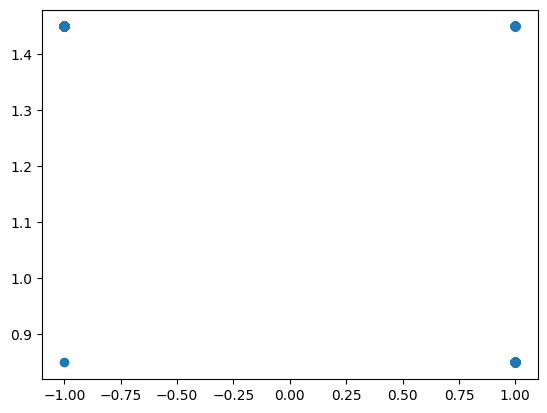

In [36]:
plt.scatter(portfolios["signal"],portfolios["return"])
plt.show()

In [37]:
pd.DataFrame(queries).sort_values("cr",ascending=False)

,profittake,leverage,stoploss,band,cr
1,0.03,15,0.01,30,8.937038e+34
0,0.03,15,0.01,15,8.970491e+33


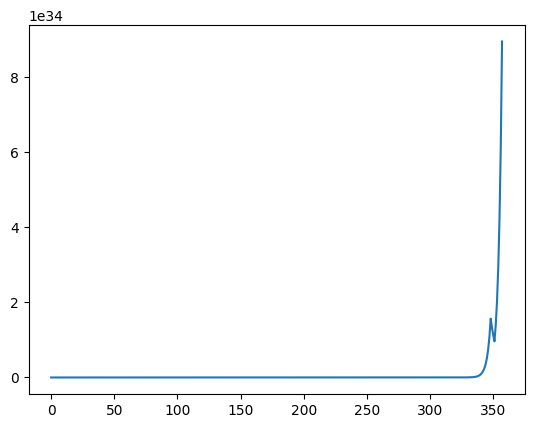

In [38]:
plt.plot(portfolios["cr"])
plt.show()

In [39]:
trades = portfolios[portfolios["return"]!=1]
trades

,filled,buy_price,sell_price,signal,buy_time,sell_time,return,cr
0,True,0.4805,0.466085,-1,2023-09-14 09:02:00,2023-09-14 13:21:00,1.45,1.450000e+02
1,True,0.4846,0.470062,-1,2023-09-14 13:22:00,2023-09-14 17:15:00,1.45,2.102500e+02
2,True,0.4899,0.475203,-1,2023-09-14 17:16:00,2023-09-15 02:03:00,1.45,3.048625e+02
3,True,0.4962,0.481314,-1,2023-09-15 02:04:00,2023-09-15 04:46:00,1.45,4.420506e+02
4,True,0.5039,0.488783,-1,2023-09-15 04:47:00,2023-09-15 14:47:00,1.45,6.409734e+02
...,...,...,...,...,...,...,...,...
353,True,0.5612,0.544364,-1,2024-02-18 17:05:00,2024-02-19 22:04:00,1.45,2.021723e+34
354,True,0.5674,0.550378,-1,2024-02-19 22:05:00,2024-02-20 03:46:00,1.45,2.931498e+34
355,True,0.5722,0.555034,-1,2024-02-20 03:47:00,2024-02-20 15:29:00,1.45,4.250672e+34
356,True,0.5501,0.566603,1,2024-02-20 15:30:00,2024-02-20 23:09:00,1.45,6.163475e+34


In [ ]:
trades.to_csv("rolling_average_trades.csv")